In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

y = to_categorical(y)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)


X Shape: (150, 4)
Y Shape: (150, 3)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Standardized")


Data Standardized


In [5]:
model = Sequential()

model.add(Input(shape=(4,)))

model.add(Dense(10, activation="relu"))

model.add(Dense(8, activation="relu"))

model.add(Dense(3, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165 (660.00 B)

 Trainable params: 165 (660.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled")

Model Compiled


In [7]:

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=5,
    verbose=0
)

print("Training Completed")

Training Completed


In [8]:

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

Test Accuracy: 1.0
Test Loss: 0.06268206983804703


In [9]:
y_pred = model.predict(X_test, verbose=0)

y_pred_classes = np.argmax(y_pred, axis=1)

y_test_classes = np.argmax(y_test, axis=1)

print("Predictions:")
print(y_pred_classes)

Predictions:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [10]:
cm = confusion_matrix(
    y_test_classes,
    y_pred_classes
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [11]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_classes,
        y_pred_classes,
        target_names=iris.target_names
    )
)



Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



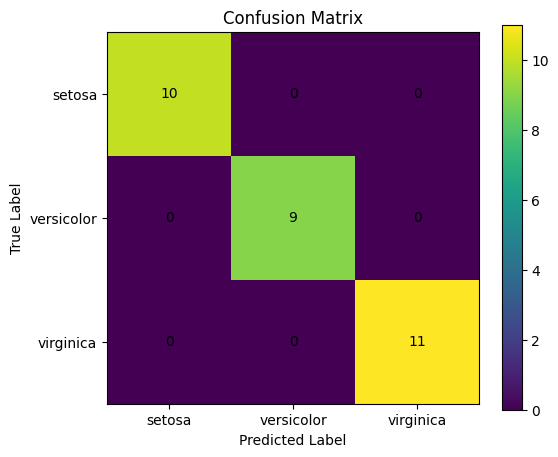

In [12]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(3),
    iris.target_names
)

plt.yticks(
    range(3),
    iris.target_names
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()